# H&M Customer Preference and Product Ranking

**Owner:** Binara  
**Module:** CCS4310 – Deep Learning  
**Project:** Explainable-Fashion-Design-AI

This notebook reads the preprocessing outputs from disk, compares popularity and practical preference models, and evaluates recommendation lists with ranking metrics. Development results are not final project results. No SHAP workflow is implemented; explainability is owned by Dewmi.

In [1]:
from pathlib import Path
import json
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

RANDOM_STATE=42
FAST_DEV_RUN=True
FINAL_EVALUATION=False
RUN_NCF_TRAINING=False
TOP_K=12
RECENT_POPULARITY_DAYS=30
np.random.seed(RANDOM_STATE)

def root():
    for p in [Path.cwd().resolve(),*Path.cwd().resolve().parents]:
        if (p/'data/interim').is_dir() and (p/'requirements.txt').exists(): return p
    raise FileNotFoundError('Repository root not found.')

ROOT=root(); INTERIM=ROOT/'data/interim'; METRICS=ROOT/'outputs/metrics'; FIGURES=ROOT/'outputs/figures'; MODEL_DIR=ROOT/'models/preference'
for d in [METRICS,FIGURES,MODEL_DIR]: d.mkdir(parents=True,exist_ok=True)


def required(name):
    path = INTERIM / name
    if not path.exists():
        raise FileNotFoundError(f'Missing required input: {path}')
    return path


def load_feature_frame(name, time_column):
    frame = pd.read_csv(required(name))
    required_columns = {'customer_id', 'article_id', 'target', time_column}
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(
            f'{name} is missing required columns {sorted(missing)}; '
            f'available columns are {list(frame.columns)}'
        )
    frame[time_column] = pd.to_datetime(frame[time_column], errors='raise')
    return frame


config = json.loads(required('hm_preference_feature_config.json').read_text(encoding='utf-8'))
time_column = config.get('time_column', 't_dat')
train = load_feature_frame('hm_preference_train.csv', time_column)
valid = load_feature_frame('hm_preference_validation.csv', time_column)
test = load_feature_frame('hm_preference_test.csv', time_column)

print('Using existing shared repository .venv / selected project kernel:',sys.executable)
if FAST_DEV_RUN: print('DEVELOPMENT / PIPELINE VALIDATION RESULTS ONLY')
print('Configured time column:', time_column)
print('Loaded rows:',len(train),len(valid),len(test))


Using existing shared repository .venv / selected project kernel: d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\.venv\Scripts\python.exe
DEVELOPMENT / PIPELINE VALIDATION RESULTS ONLY
Configured time column: t_dat
Loaded rows: 2877 577 434


In [2]:
summary=json.loads(required('hm_preference_preprocessing_summary.json').read_text(encoding='utf-8'))
if 'date_ranges' not in summary or not all(k in summary['date_ranges'] for k in ['train', 'validation', 'test']):
    raise ValueError("Preprocessing summary is missing 'date_ranges' for train/validation/test. Run 04_hm_preprocessing.ipynb first.")
for frame_name, df in [('train',train),('validation',valid),('test',test)]:
    required_columns={'customer_id','article_id','target',time_column}
    missing=required_columns.difference(df.columns)
    if missing:
        raise ValueError(f'{frame_name} is missing columns {sorted(missing)}; available columns are {list(df.columns)}')
print('Loaded rows:',len(train),len(valid),len(test))
print('Configured time column:',time_column)
print('Train date range:',summary['date_ranges']['train'])
print('Validation date range:',summary['date_ranges']['validation'])
print('Test date range:',summary['date_ranges']['test'])
print('Recent popularity window:',RECENT_POPULARITY_DAYS,'days before each history cutoff')
assert not any(c in config['numerical_features'] for c in config['identifier_columns'])
assert 'price' not in config['numerical_features'], 'Current transaction price must not be a model feature.'

Loaded rows: 2877 577 434
Configured time column: t_dat
Train date range: ['2018-09-20 00:00:00', '2018-09-23 00:00:00']
Validation date range: ['2018-09-24 00:00:00', '2018-09-24 00:00:00']
Test date range: ['2018-09-25 00:00:00', '2018-09-25 00:00:00']
Recent popularity window: 30 days before each history cutoff


In [3]:
def ranking_metrics(frame, score_col='score', k=TOP_K):
    aps = []
    recalls = []
    ndcgs = []
    candidate_sizes = []
    for cid, raw in frame.groupby('customer_id', sort=False):
        ranked = raw.sort_values([score_col, 'article_id'], ascending=[False, True], kind='mergesort').drop_duplicates('article_id')
        candidate_sizes.append(len(ranked))
        relevant = set(ranked.loc[ranked.target.eq(1), 'article_id'])
        if not relevant:
            continue
        if len(ranked) < k:
            top = ranked.copy()
        else:
            top = ranked.head(k).copy()
        hits = 0
        precision_sum = 0.0
        dcg = 0.0
        for rank, row in enumerate(top.itertuples(index=False), start=1):
            rel = int(getattr(row, 'target', 0) == 1)
            if rel:
                hits += 1
                precision_sum += hits / rank
                dcg += 1 / np.log2(rank + 1)
        ap = precision_sum / min(len(relevant), k)
        recall = hits / len(relevant)
        idcg = sum(1 / np.log2(rank + 1) for rank in range(1, min(len(relevant), k) + 1))
        ndcg = dcg / idcg if idcg else 0.0
        aps.append(ap)
        recalls.append(recall)
        ndcgs.append(ndcg)

    if candidate_sizes:
        candidate_sizes = np.asarray(candidate_sizes, dtype=float)
        print(f'Candidate pool stats: median={np.median(candidate_sizes):.1f}, min={candidate_sizes.min():.1f}, max={candidate_sizes.max():.1f}')
        assert (candidate_sizes > TOP_K).any(), 'Candidate pool must be larger than TOP_K for ranking evaluation.'

    return {'MAP@12': float(np.mean(aps)) if aps else 0.0, 'Recall@12': float(np.mean(recalls)) if recalls else 0.0, 'NDCG@12': float(np.mean(ndcgs)) if ndcgs else 0.0}


def popularity_scores(frame, recent=False):
    out = frame.copy()
    column = 'recent_article_popularity' if recent else 'historical_article_popularity'
    out['score'] = pd.to_numeric(out[column], errors='coerce').fillna(0.0)
    return out


def category_scores(frame):
    out = frame.copy()
    preferred = out.get('preferred_category', pd.Series('UNKNOWN', index=out.index)).fillna('UNKNOWN').astype(str)
    category = out.get('product_group_name', pd.Series('UNKNOWN', index=out.index)).fillna('UNKNOWN').astype(str)
    out['score'] = (preferred == category).astype(float)
    out.loc[out['score'].eq(0), 'score'] = out.loc[out['score'].eq(0), 'recent_article_popularity'].astype(float)
    return out


def score_named(name, frame):
    out = frame.copy()
    if name == 'Global Popularity':
        out = popularity_scores(out, recent=False)
    elif name == 'Recent Popularity':
        out = popularity_scores(out, recent=True)
    elif name == 'Category Preference':
        out = category_scores(out)
    else:
        out['score'] = pd.to_numeric(out.get('score', 0), errors='coerce').fillna(0.0)
    return out


def evaluate(name, frame, split='validation'):
    m = ranking_metrics(frame)
    return {'model': name, 'run_type': 'fast_dev' if FAST_DEV_RUN else 'full', f'{split}_MAP@12': m['MAP@12'], f'{split}_Recall@K': m['Recall@12'], f'{split}_NDCG@K': m['NDCG@12']}


In [4]:
# Fit all transformations on TRAIN only; IDs, target, split, and current transaction fields are excluded.
leakage={'customer_id','article_id','target','split',time_column,'sales_channel_id','price'}
feature_cols=[c for c in train.columns if c not in leakage]
cat=[c for c in config['categorical_features'] if c in feature_cols]
num=[c for c in config['numerical_features'] if c in feature_cols]
pre=ColumnTransformer([('num',SimpleImputer(strategy='median'),num),('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat)],remainder='drop')
logistic=Pipeline([('preprocess',pre),('classifier',LogisticRegression(max_iter=250,random_state=RANDOM_STATE,class_weight='balanced'))])

baseline_results=[]
for name in ['Global Popularity','Recent Popularity','Category Preference']:
    baseline_results.append(evaluate(name, score_named(name, valid), 'validation'))

candidate_results=[]; candidate_pipelines={}
if train.target.nunique()>1 and feature_cols:
    try:
        logistic.fit(train[feature_cols],train.target.astype(int)); scored=valid.copy(); scored['score']=logistic.predict_proba(valid[feature_cols])[:,1]
        candidate_results.append(evaluate('Logistic Regression',scored,'validation')); candidate_pipelines['Logistic Regression']=logistic
    except Exception as exc: print('Logistic Regression skipped:',exc)
else: print('Logistic Regression skipped: training data has fewer than two target classes or no usable features.')
try:
    from lightgbm import LGBMClassifier
    lightgbm_model=Pipeline([('preprocess',pre),('classifier',LGBMClassifier(n_estimators=120,learning_rate=0.05,num_leaves=31,random_state=RANDOM_STATE,verbosity=-1))])
    lightgbm_model.fit(train[feature_cols],train.target.astype(int)); lgb_scored=valid.copy(); lgb_scored['score']=lightgbm_model.predict_proba(valid[feature_cols])[:,1]
    candidate_results.append(evaluate('LightGBM',lgb_scored,'validation')); candidate_pipelines['LightGBM']=lightgbm_model
except ImportError:
    print('LightGBM is not installed in the existing shared project .venv environment; this optional model will be skipped.')
except Exception as exc:
    print('LightGBM skipped:',exc)

validation_results=pd.DataFrame(baseline_results + candidate_results)
if validation_results.empty:
    winner='Global Popularity'; selection_metric='validation_MAP@12'
else:
    winner_row = validation_results.sort_values(['validation_MAP@12','validation_Recall@K','validation_NDCG@K'], ascending=[False, False, False]).iloc[0]
    winner = str(winner_row['model'])
    selection_metric = 'validation_MAP@12'

display(validation_results)
validation_results.to_csv(METRICS/'customer_preference_model_results.csv',index=False)

Candidate pool stats: median=31.5, min=31.0, max=36.0
Candidate pool stats: median=31.5, min=31.0, max=36.0
Candidate pool stats: median=31.5, min=31.0, max=36.0
Candidate pool stats: median=31.5, min=31.0, max=36.0
Candidate pool stats: median=31.5, min=31.0, max=36.0


,model,run_type,validation_MAP@12,validation_Recall@K,validation_NDCG@K
0,Global Popularity,fast_dev,0.408123,0.831481,0.533582
1,Recent Popularity,fast_dev,0.408123,0.831481,0.533582
2,Category Preference,fast_dev,0.413530,0.861111,0.551794
3,Logistic Regression,fast_dev,0.353912,0.731481,0.460760
4,LightGBM,fast_dev,0.362051,0.666667,0.459130


In [5]:
final_models=list(dict.fromkeys([winner,'Global Popularity','Recent Popularity','Category Preference'] + list(candidate_pipelines)))
test_rows=[]
winner_test_scored=None
for name in final_models:
    if name in candidate_pipelines:
        scored=test.copy()
        scored['score']=candidate_pipelines[name].predict_proba(test[feature_cols])[:,1]
    else:
        scored=score_named(name, test)
    if name == winner:
        winner_test_scored=scored
    m=ranking_metrics(scored)
    test_rows.append({'model':name,'run_type':'fast_dev' if FAST_DEV_RUN else 'full','test_MAP@12':m['MAP@12'],'test_Recall@K':m['Recall@12'],'test_NDCG@K':m['NDCG@12']})
test_results=pd.DataFrame(test_rows); display(test_results); test_results.to_csv(METRICS/'customer_preference_final_test_results.csv',index=False)
selected_artifact=candidate_pipelines.get(winner,{'model_type':winner,'note':'Serializable baseline configuration; no fitted ML model claimed.'})
if winner in {'Global Popularity','Recent Popularity','Category Preference'}:
    selected_artifact = {'model_type': winner, 'note': 'Baseline recommendation policy; no fitted ML model was trained.'}
joblib.dump(selected_artifact,MODEL_DIR/'best_customer_preference_model.joblib')
model_config={'selected_model':winner,'selection_metric':selection_metric,'TOP_K':TOP_K,'recent_popularity_days':RECENT_POPULARITY_DAYS,'candidate_pool_policy':config['candidate_pool_policy'],'negative_sampling_policy':config['negative_sampling_policy'],'feature_columns':feature_cols,'run_type':'fast_dev' if FAST_DEV_RUN else 'full','fast_dev_run':FAST_DEV_RUN,'final_evaluation':FINAL_EVALUATION,'leakage_exclusions':sorted(leakage)}
(MODEL_DIR/'customer_preference_model_config.json').write_text(json.dumps(model_config,indent=2),encoding='utf-8')

Candidate pool stats: median=33.0, min=31.0, max=40.0
Candidate pool stats: median=33.0, min=31.0, max=40.0
Candidate pool stats: median=33.0, min=31.0, max=40.0
Candidate pool stats: median=33.0, min=31.0, max=40.0
Candidate pool stats: median=33.0, min=31.0, max=40.0


,model,run_type,test_MAP@12,test_Recall@K,test_NDCG@K
0,Category Preference,fast_dev,0.250273,0.617308,0.384268
1,Global Popularity,fast_dev,0.423605,0.603846,0.519130
2,Recent Popularity,fast_dev,0.423605,0.603846,0.519130
3,Logistic Regression,fast_dev,0.542911,0.754487,0.641772
4,LightGBM,fast_dev,0.472165,0.752564,0.594132


1282

,customer_display_id,rank,article_id,product_type_name,garment_group_name,colour_group_name,score
10,00b5bd53…,1,433444007,T-shirt,Jersey Fancy,Dark Blue,1.0
1,00b5bd53…,2,504152011,Cardigan,Knitwear,Light Beige,1.0
20,00b5bd53…,3,521062011,Hoodie,Jersey Fancy,Light Beige,1.0
13,00b5bd53…,4,541308009,Hoodie,Jersey Basic,Greenish Khaki,1.0
16,00b5bd53…,5,545266001,Sweater,Knitwear,Dark Green,1.0
0,00b5bd53…,6,578480001,Coat,Outdoor,Dark Blue,1.0
19,00b5bd53…,7,579541009,Cardigan,Knitwear,Grey,1.0
28,00b5bd53…,8,614734001,Pumps,Shoes,Orange,1.0
2,00b5bd53…,9,648738021,Sweater,Jersey Fancy,Other Red,1.0
27,00b5bd53…,10,656437002,Sweater,Knitwear,Dark Blue,1.0


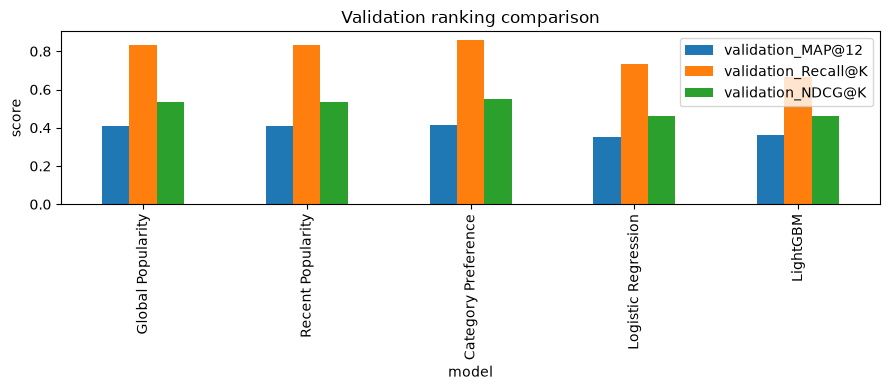

Validation winner selected by validation_MAP@12: Category Preference
Test comparisons were run only after winner selection; no test result selected the winner.
Cold start: new customers fall back to recent/global popularity; new products use available article metadata. No sensitive traits or visual embeddings are inferred.
Limitations: FAST_DEV_RUN uses a capped reproducible transaction subset; rerun with FAST_DEV_RUN=False and FINAL_EVALUATION=True for final project evaluation.


In [6]:
# Anonymous recommendation demonstration with unique article IDs and metadata only.
demo=(winner_test_scored.sort_values(['customer_id','score','article_id'],ascending=[True,False,True]).drop_duplicates(['customer_id','article_id']).groupby('customer_id').head(TOP_K).copy())
demo['rank']=demo.groupby('customer_id').cumcount()+1
demo['customer_display_id']=demo['customer_id'].str[:8]+'…'
display(demo[['customer_display_id','rank','article_id','product_type_name','garment_group_name','colour_group_name','score']].head(30))
fig,ax=plt.subplots(figsize=(9,4)); plot_df=validation_results.set_index('model')[['validation_MAP@12','validation_Recall@K','validation_NDCG@K']]; plot_df.plot.bar(ax=ax,title='Validation ranking comparison'); ax.set_ylabel('score'); plt.tight_layout(); plt.savefig(FIGURES/'binara_preference_validation_metrics.png',dpi=120); plt.show(); plt.close()
print(f'Validation winner selected by {selection_metric}: {winner}')
print('Test comparisons were run only after winner selection; no test result selected the winner.')
print('Cold start: new customers fall back to recent/global popularity; new products use available article metadata. No sensitive traits or visual embeddings are inferred.')
print('Limitations: FAST_DEV_RUN uses a capped reproducible transaction subset; rerun with FAST_DEV_RUN=False and FINAL_EVALUATION=True for final project evaluation.')